<a href="https://colab.research.google.com/github/pavlovado/Natural-language-processing/blob/main/NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Загрузка датасета

Для реализации задачи был использован открытый набор данных [IMDB Movie Reviews](https://www.kaggle.com/datasets/vishakhdapat/imdb-movie-reviews/data), скачанный с [kaggle.com](https://www.kaggle.com).

Набор данных создан для задач определения тональности текста. Он включает отзывы на фильмы с сайта IMDb. Отзывы только явно положительные (оценка >= 7) или отрицательные (оценка <= 4), нейтральные отзывы в набор данных не включались.

Размер набора данных 50 тыс. отзывов:

*   Набор данных для обучения – 35 тыс. отзывов (70%)
*   Набор данных для тестирования - 15 тыс. отзывов (30%)

Количество положительных и отрицательных отзывов одинаковое.

Разметка набора данных:

*   0 - отзыв отрицательный
*   1 - отзыв положительный

С точки зрения машинного обучения это задача бинарной классификации.

Импортируем необходимые библиотеки и пакеты для работы с нейронными сетями, а также загрузим датасет.
* ` numpy ` – для работы с многомерными массивами и матрицами.
* ` matplotlib.pyplot ` – построение графиков и отображения изображений.
* ` sklearn ` – содержит функции и алгоритмы для машинного обучения: классификации, прогнозирования или разбивки данных на группы.
* ` tensorflow, keras ` – для создания и обучения нейронных сетей.

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import LSTM, Embedding, Dense, Dropout, GlobalMaxPooling1D
from tensorflow.keras.models import Sequential
import random

dataset = tfds.load('imdb_reviews', with_info=False, as_supervised=True)

# Предобработка текста

Разделение на обучающую и тестовую выборки осуществляется на основе предварительно установленного деления внутри датасета.

Выведем несколько примеров. Каждый элемент представляет собой пару: текстовый отзыв и метка. Поскольку текстовые данные в TensorFlow хранятся в формате байтов, метод `.decode('utf-8')` преобразует их в строку в кодировке UTF-8.


In [ ]:
train_data, test_data = dataset['train'], dataset['test']

for i, (text, label) in enumerate(train_data.take(5)):
    print(f"Текст: {text.numpy().decode('utf-8')}")
    print(f"Метка: {label.numpy()}")

Текст: This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it.
Метка: 0
Текст: I have been known to fall asleep during films, but this is usually due to a combination of things including, really tired, being warm and comfortable on the sette and having just eaten a lot. However on this occasion I fell asleep because the film was rubbish. The pl

Выполним два этапа предобработки текста с помощью функции `clean_text`:


1.   Удаление лишних символов (с помощью регулярного выражения `[^a-zA-Z\s]` удаляются все символы, кроме букв английского алфавита и пробелов).
2.   Приведение к нижнему регистру.

После применения функции ко всем элементам выведем те же примеры отзывов, но уже после предобработки.


In [ ]:
def clean_text(text, label):
    text = tf.strings.regex_replace(text, rb"[^a-zA-Z\s]", b"")
    return tf.strings.lower(text), label

train_data = train_data.map(clean_text)
test_data = test_data.map(clean_text)

for i, (text, label) in enumerate(train_data.take(5)):
    print(f"Текст: {text.numpy().decode('utf-8')}")
    print(f"Метка: {label.numpy()}")

Текст: this was an absolutely terrible movie dont be lured in by christopher walken or michael ironside both are great actors but this must simply be their worst role in history even their great acting could not redeem this movies ridiculous storyline this movie is an early nineties us propaganda piece the most pathetic scenes were those when the columbian rebels were making their cases for revolutions maria conchita alonso appeared phony and her pseudolove affair with walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning i am disappointed that there are movies like this ruining actors like christopher walkens good name i could barely sit through it
Метка: 0
Текст: i have been known to fall asleep during films but this is usually due to a combination of things including really tired being warm and comfortable on the sette and having just eaten a lot however on this occasion i fell asleep because the film was rubbish the plot development was con

# Токенизация текста

Нейронная сеть может обрабатывать только числа, а текст – это набор символов. Поэтому необходимо из набора символов получить набор чисел.

Для начала нужно разбить текст на более мелкие части, что называется **токенизацией.** После этого токены можно преобразовать в набор чисел, то есть произвести **векторизацию.**

Создадим объект `TextVectorization`, который будет использоваться для преобразования текста в числовые последовательности целых чисел. Параметр `max_tokens=10000` ограничивает количество уникальных токенов в словаре, которые будут учтены при векторизации. Если в тексте встречается больше уникальных слов, то слова с более низкой частотой будут проигнорированы. Все векторизованные тексты будут иметь одинаковую длину — 200 токенов. Если текст длиннее, он будет обрезан, а если короче — дополнен нулями. Паддинг встроен в процесс токенизации благодаря параметру `output_sequence_length`. Нам не нужно будет отдельно использовать `pad_sequences`, так как`TextVectorization` выполняет эту задачу автоматически.

При помощи `tokenizer.adapt` токенизатор просматривает все текстовые данные, чтобы построить словарь токенов и определить их частоту. После того, как текст разделен на токены, каждому токену присваивается уникальный индекс. Когда текст проходит через токенизатор, каждый токен заменяется на его индекс из словаря. Эти индексы составляют числовую последовательность, которую затем подают в нейронную сеть.

Далее конвертируем данные из формата `tf.data.Dataset` в формат `NumPy` массивов, чтобы они стали удобными для обработки и передачи в модель машинного обучения.



In [ ]:
tokenizer = tf.keras.layers.TextVectorization(max_tokens=10000, output_mode='int', output_sequence_length=200)
train_text = train_data.map(lambda x, y: x)  # извлекаем только текстовые данные
tokenizer.adapt(train_text)

# преобразуем тексты в последовательности чисел
X_train = train_data.map(lambda x, y: tokenizer(x))
X_test = test_data.map(lambda x, y: tokenizer(x))

# получаем векторы меток
y_train = train_data.map(lambda x, y: y)
y_test = test_data.map(lambda x, y: y)

X_train = np.array(list(X_train))
X_test = np.array(list(X_test))
y_train = np.array(list(y_train))
y_test = np.array(list(y_test))

text = train_data.take(1).get_single_element()[0].numpy().decode('utf-8')
tokenized_text = X_train[0]
print(f"Оригинальный текст: {text}")
print(f"Токенизированный текст: {tokenized_text}")

Оригинальный текст: this was an absolutely terrible movie dont be lured in by christopher walken or michael ironside both are great actors but this must simply be their worst role in history even their great acting could not redeem this movies ridiculous storyline this movie is an early nineties us propaganda piece the most pathetic scenes were those when the columbian rebels were making their cases for revolutions maria conchita alonso appeared phony and her pseudolove affair with walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning i am disappointed that there are movies like this ruining actors like christopher walkens good name i could barely sit through it
Токенизированный текст: [  11   14   34  412  383   18   90   28    1    8   33 1309 3488   42
  483    1  192   24   85  152   19   11  218  315   28   65  241  216
    8  485   54   65   85  112   96   22 5517   11   93  638  737   11
   18    7   34  393 9374  171 2438  407    2   88

# Создание модели нейронной сети

Модель представляет собой архитектуру с использованием рекуррентных нейронных сетей (RNN). Основное их отличие от сверточных нейронных сетей заключается в наличии циклической связи между нейронами, что позволяет им учитывать информацию из предыдущих элементов последовательности.

Начальный слой — это `Embedding`, который присваивает каждому числовому индексу многомерный вектор. В процессе обучения значения векторов адаптируются. Вектора обновляются с учетом контекста слов в предложении, задачей модели и ее ошибок на тренировке.

После того, как слова превращены в векторы, их нужно обработать, чтобы понять их смысл в контексте предложения. Для этого используются два слоя `LSTM`. Слой включает в себя специальные ячейки памяти, которые могут запоминать информацию на длительные промежутки времени. Внутри `LSTM` есть гейт-система (вентили), которые управляют тем, какую информацию «помнить» и «забывать», в зависимости от текущего контекста.

Для предотвращения переобучения добавлены два слоя `Dropout`, которые отключают указанный процент нейронов, улучшая обобщающие способности модели.

Модель завершается несколькими слоями `Dense`, которые классифицируют текст по тональностям с использованием активации `sigmoid` для бинарной классификации.

В качестве оптимизатора выбран `Adam`. Функция потерь — `categorical crossentropy`, которая используется для задач бинарной классификации. Для оценки производительности использована метрика точности `accuracy`, которая отслеживает долю правильных предсказаний. `Accuracy` показывает, какой процент из всех предсказанных примеров был правильным. `Precision` показывает, какой процент положительных предсказаний действительно является положительными.

In [ ]:
model = Sequential([
    Embedding(input_dim=10000, output_dim=128), # размер словаря и вектора
    LSTM(128, return_sequences=True), # возвращает всю последовательность выходных векторов для каждого временного шага
    Dropout(0.2),
    LSTM(64), # возвращает вектор состояния на последнем временном шаге
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.summary()

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 200, 128)            │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 200, 128)            │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 200, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,463,105 (5.58 MB)

 Trainable params: 1,463,105 (5.58 MB)

 Non-trainable params: 0 (0.00 B)

# Обучение модели



С помощью функции `split` разделим данные на обучающую и валидационную выборки. Доля данные для валидации – 20% от обучающей выборки.

**Batch size** — это количество обучающих примеров, которые обрабатываются одновременно перед тем, как веса модели будут обновлены. Модель пропускает 64 примера через слои, вычисляет предсказания, затем вычисляет ошибку и обновляет веса модели, используя методы оптимизации.






In [ ]:
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train, y_train, test_size=0.2)
history = model.fit(X_train_split, y_train_split, epochs=10, batch_size=64, validation_data=(X_val_split, y_val_split))

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 261s 820ms/step - accuracy: 0.5046 - loss: 0.6940 - val_accuracy: 0.5092 - val_loss: 0.6865
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 267s 838ms/step - accuracy: 0.4993 - loss: 0.7001 - val_accuracy: 0.4848 - val_loss: 0.7003
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 267s 853ms/step - accuracy: 0.5074 - loss: 0.6944 - val_accuracy: 0.5152 - val_loss: 0.6929
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 312s 822ms/step - accuracy: 0.5048 - loss: 0.6940 - val_accuracy: 0.4848 - val_loss: 0.6958
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 264s 826ms/step - accuracy: 0.4987 - loss: 0.6940 - val_accuracy: 0.5152 - val_loss: 0.6926
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 256s 817ms/step - accuracy: 0.5075 - loss: 0.6932 - val_accuracy: 0.5790 - val_loss: 0.6819
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 263s 824ms/step - accuracy: 0.5387 - loss: 0.6877 - val_accuracy: 0.5750 - val_loss: 0.6600
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 257s 822ms/step - accuracy: 0.7148 -

Создадим два графика для визуализации результатов обучения модели. Первый график отображает точность как на обучающем наборе данных, так и на валидационном, с метками для каждой эпохи. Второй график показывает потери на обучающих и валидационных данных, также с метками для каждой эпохи.

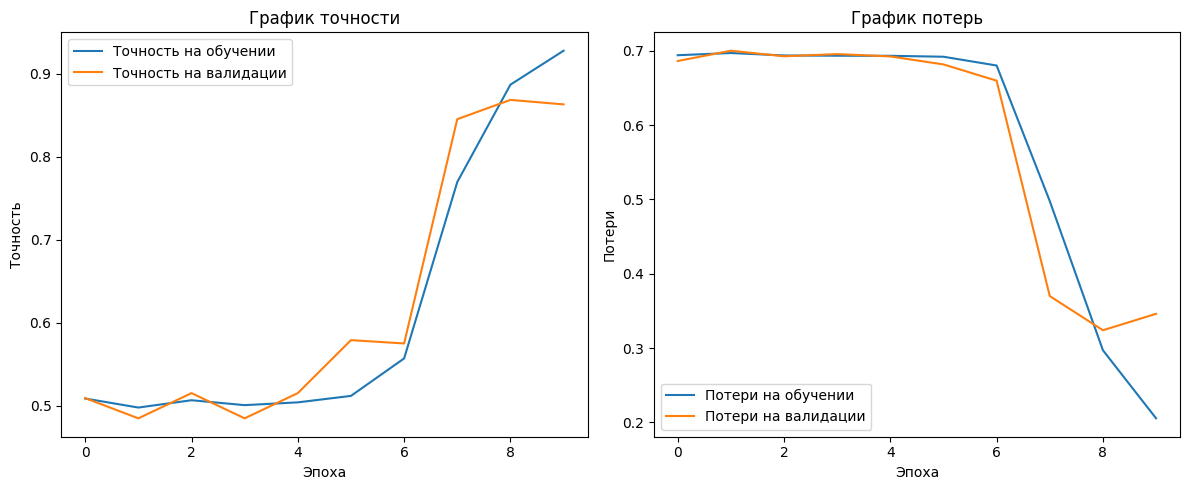

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Точность на обучении')
plt.plot(history.history['val_accuracy'], label='Точность на валидации')
plt.title('График точности')
plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Потери на обучении')
plt.plot(history.history['val_loss'], label='Потери на валидации')
plt.title('График потерь')
plt.xlabel('Эпоха')
plt.ylabel('Потери')
plt.legend()

plt.tight_layout()
plt.show()

**График точности**

Точность на обучении постоянно растет и достигает высоких значений к концу обучения.
Точность на валидации также увеличивается, но после определенного момента ее рост замедляется и становится менее выраженным.
Между двумя кривыми наблюдается незначительный разрыв, что говорит о возможном начале переобучения: модель обучается слишком хорошо на тренировочных данных, но это незначительно отражается на улучшении точности на валидации.

**График потерь**

Потери на обучении уменьшаются почти линейно, что является ожидаемым результатом для корректно настроенного обучения.
Потери на валидации также снижаются, но в какой-то момент начинают замедляться и даже немного увеличиваются к концу обучения.
Это увеличение потерь на валидации при дальнейшем снижении потерь на обучении указывает на переобучение, когда модель слишком подстраивается под обучающие данные, теряя обобщающую способность.

# Тестирование модели

Проверим модель на тестовых данных с помощью метода оценки модели. Точность составила 84.29%.

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Accuracy: {accuracy * 100:.2f}%')

782/782 ━━━━━━━━━━━━━━━━━━━━ 134s 171ms/step - accuracy: 0.8434 - loss: 0.3982
Accuracy: 84.29%


Продемонстрируем возможности модели путем предсказания меток на случайной выборке тестовых данных.

Для начала преобразуем тестовые данные в список, извлечем случайные 10 примеров и сохраним в `random_examples`. После этого пройдем по каждому примеру из случайной выборки, извлечем текст и преобразуем в utf-8. По аналогии извлечем метки.

Далее применим токенизацию, преобразуя текстовые данные в последовательности целых чисел одинаковой длины, где каждое число соответствует определенному слову или токену из словаря токенизатора.

С помощью функции `predict` получим предсказаний модели на основе входных данных. Входные данные — это матрица, где каждая строка соответствует одной последовательности токенов, выровненной до фиксированной длины. Также применим округление вероятностей, чтобы результаты можно было интерпретировать как метки классов, и уберем лишние измерения, если результат оказался многомерным массивом.

In [ ]:
def predict_examples(model, tokenizer, test_data, max_len, label_map):
    test_examples = list(test_data.as_numpy_iterator())
    random_examples = random.sample(test_examples, 10)

    texts = [example[0].decode('utf-8') for example in random_examples]
    labels = [example[1] for example in random_examples]

    sequences = tokenizer(texts)

    predictions = model.predict(sequences)
    predicted_labels = np.round(predictions).astype(int).flatten()

    print("\nПримеры предсказаний:")
    for i, (text, true_label, predicted_label) in enumerate(zip(texts, labels, predicted_labels)):
        print(f"Пример {i+1}:")
        print(f"Текст: {text}")
        print(f"Правильная метка: {label_map[true_label]}")
        print(f"Предсказанная метка: {label_map[predicted_label]}")
        print("-" * 50)

label_map = {0: "Отрицательный", 1: "Положительный"}
predict_examples(model, tokenizer, test_data, max_len=200, label_map=label_map)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step

Примеры предсказаний:
Пример 1:
Текст: andaz apna apna is by far my second favorite comedy of all time first being namak halal even though that was technically a drama story is nothing groundbreaking but the complications that are added to it make it awesome aamir khan is a total cartoon just watch his expressions in the song yeh raat aur yeh doori he is amazingly good at comedy i never knew salman khan was also good as the somewhat dimmer of the two characters the noises he makes are almost as funny as aamirs faces raveena and karisma serve their purpose but are nothing amazing the real pick of the lot is paresh rawal as usualbr br the plot is rather simple amar aamir and prem salman are useless sons of poor fathers they dont believe in hard work and just want to get rich the easy way so both their brains come across an idea to woo a rich mans paresh rawal daughter raveena tandon who comes to india to look for a husband so amar and prem meet on t

Предскажем тональность текста у отзывов, которые были придуманы сами.

Очищаем текст от лишних символом и приводим к нижнему регистру. Разбиваем отзывы на два списка:

1.   Текстовые отзывы в виде кортежа (отзыв, метка).
2.   Метки истинных классов для каждого отзыва.

С помощью токенизатора преобразуем очищенные тексты в числовые последовательности индексов слов или подслов. Задаем фиксированную длину каждой последовательности. После этого получаем предсказания модели.


In [ ]:
def predict_custom_examples(model, tokenizer, custom_reviews_with_labels, max_len, label_map):

    def clean_text(text):
        text = tf.strings.regex_replace(text, rb"[^a-zA-Z\s]", b"").numpy().decode('utf-8')
        return text.lower()

    custom_texts = [review[0] for review in custom_reviews_with_labels]
    true_labels = [review[1] for review in custom_reviews_with_labels]
    cleaned_texts = [clean_text(tf.constant(text)) for text in custom_texts]

    sequences = tokenizer(cleaned_texts)

    predictions = model.predict(sequences)
    predicted_labels = np.round(predictions).astype(int).flatten()

    print("\nПримеры предсказаний для пользовательских отзывов:")
    for i, (text, true_label, predicted_label) in enumerate(zip(custom_texts, true_labels, predicted_labels)):
        print(f"Отзыв: {text}")
        print(f"Правильная метка: {label_map[true_label]}")
        print(f"Предсказанная метка: {label_map[predicted_label]}")
        print("-" * 50)

custom_reviews_with_labels = [
    ("The movie was fantastic! The characters were well-developed and the plot was gripping.", 1),
    ("I didn’t like the movie. It was too slow and the acting was terrible.", 0),
    ("An average film. Not bad, but not great either.", 0),
    ("Absolutely loved it! Would watch again.", 1),
    ("Terrible movie. Waste of time.", 0),
]

predict_custom_examples(model, tokenizer, custom_reviews_with_labels, max_len=200, label_map=label_map)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

Примеры предсказаний для пользовательских отзывов:
Отзыв: The movie was fantastic! The characters were well-developed and the plot was gripping.
Правильная метка: Положительный
Предсказанная метка: Положительный
--------------------------------------------------
Отзыв: I didn’t like the movie. It was too slow and the acting was terrible.
Правильная метка: Отрицательный
Предсказанная метка: Отрицательный
--------------------------------------------------
Отзыв: An average film. Not bad, but not great either.
Правильная метка: Отрицательный
Предсказанная метка: Отрицательный
--------------------------------------------------
Отзыв: Absolutely loved it! Would watch again.
Правильная метка: Положительный
Предсказанная метка: Положительный
--------------------------------------------------
Отзыв: Terrible movie. Waste of time.
Правильная метка: Отрицательный
Предсказанная метка: Отрицательный
--------------------------------------------------
